<a href="https://colab.research.google.com/github/daviseemann/turbofan-rul-prediction-cmapss/blob/production/notebooks/MLP-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount(
    "/content/drive/",
)
import os

os.chdir(
    "/content/drive/MyDrive/Data science studies/Aprendizado-de-maquina-UFSC/final-project/data"
)

Mounted at /content/drive/


In [3]:
# Caminhos dos arquivos
train_path = "./6.turbofan rul/train_FD001.txt"
test_path = "./6.turbofan rul/test_FD001.txt"
rul_path = "./6.turbofan rul/RUL_FD001.txt"

# Nomes das colunas (de acordo com a documentação original do C-MAPSS)
column_names = (
    ["engine_id", "cycle"]
    + [f"op{i}" for i in range(1, 4)]
    + [f"s{i}" for i in range(1, 22)]
)

# Importando os arquivos (espaço em branco como delimitador)
df_train = pd.read_csv(train_path, sep="\s+", header=None, names=column_names)
df_test = pd.read_csv(test_path, sep="\s+", header=None, names=column_names)
df_rul = pd.read_csv(rul_path, sep="\s+", header=None, names=["RUL"])

In [4]:
display(df_train.head())
display(df_test.head())
display(df_rul.head())

,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


,RUL
0,112
1,98
2,69
3,82
4,91


# Pré-processamento


### Seleção de Sensores

O artigo menciona que apenas 14 dos 21 sensores são usados. Vamos selecionar os mesmos:


In [5]:
# Sensores selecionados conforme o artigo
selected_sensors = [
    "s2",
    "s3",
    "s4",
    "s7",
    "s8",
    "s9",
    "s11",
    "s12",
    "s13",
    "s14",
    "s15",
    "s17",
    "s20",
    "s21",
]

# Colunas que vamos manter
features_to_keep = ["engine_id", "cycle"] + selected_sensors

# Filtrando os dataframes
df_train = df_train[features_to_keep]
df_test = df_test[features_to_keep]

### Normalização dos Dados

O artigo usa normalização min-max para o intervalo [-1, 1]:


In [6]:
from sklearn.preprocessing import MinMaxScaler

def min_max_normalize(train_df, test_df, features):
    """Normaliza as features para o intervalo [-1, 1] sem data leakage"""
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler.fit(train_df[features])  # Ajusta apenas no treino

    # Aplica a transformação no treino e no teste
    train_df[features] = scaler.transform(train_df[features])
    test_df[features] = scaler.transform(test_df[features])

    return train_df, test_df, scaler

# Normalizando os dados
features_to_normalize = selected_sensors
df_train, df_test, scaler = min_max_normalize(df_train, df_test, features_to_normalize)

### Criando os RULs para Treino

O artigo usa um modelo de degradação linear por partes com RUL constante inicial (Re):


In [7]:
def create_rul_labels(df, Re, clip_at_zero=True):
    """Cria os rótulos RUL usando o modelo de degradação linear por partes"""
    grouped = df.groupby("engine_id")["cycle"].max().reset_index()
    grouped.columns = ["engine_id", "max_cycle"]

    df = df.merge(grouped, on="engine_id", how="left")
    df["RUL"] = df["max_cycle"] - df["cycle"]

    # Aplica o modelo de degradação linear por partes
    df["RUL"] = np.where(df["RUL"] > Re, Re, df["RUL"])

    return df.drop(columns=["max_cycle"])

# Usando Re=128 conforme sugerido no artigo para FD001
Re = 128
df_train = create_rul_labels(df_train, Re)

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_rul_by_engine(df, engines_to_plot=5):
    """Plota o RUL ao longo do tempo para algumas engines"""
    # Selecionar engines para visualizar
    engine_ids = df["engine_id"].unique()[:engines_to_plot]

    plt.figure(figsize=(8, 6))

    for engine_id in engine_ids:
        engine_data = df[df["engine_id"] == engine_id]
        plt.plot(engine_data["cycle"], engine_data["RUL"], label=f'Engine {engine_id}')

    plt.xlabel('Cycle')
    plt.ylabel('RUL')
    plt.title('RUL por Engine ID')
    plt.legend()
    plt.grid(True)
    plt.show()


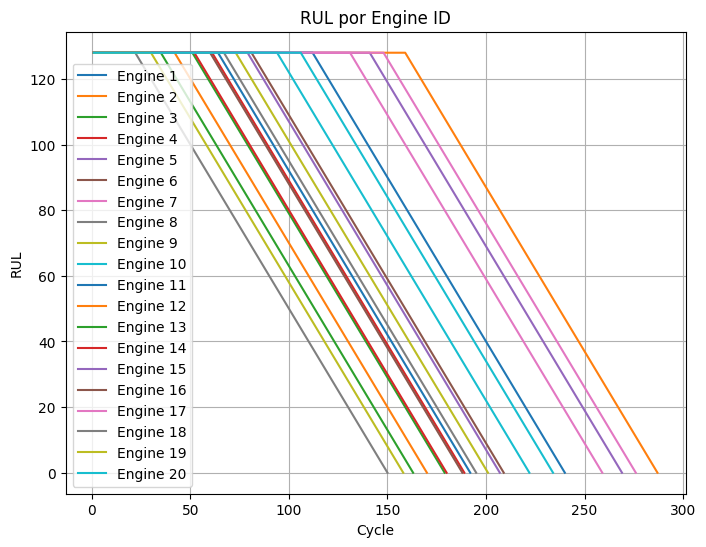

In [9]:
plot_rul_by_engine(df_train, engines_to_plot=20)

### Preparando as Janelas Temporais

O artigo usa janelas temporais com tamanho (nw) e stride (ns):


In [10]:
def create_time_windows(df, window_size, window_stride, sensor_cols):
    """Cria janelas temporais dos dados dos sensores e retorna um DataFrame com info da janela"""
    sequences = []
    labels = []
    engine_ids = []
    last_cycles = []

    for engine_id in df["engine_id"].unique():
        engine_data = df[df["engine_id"] == engine_id]
        sensor_data = engine_data[sensor_cols].values
        rul_data = engine_data["RUL"].values

        # Cria janelas deslizantes
        for i in range(0, len(engine_data) - window_size + 1, window_stride):
            window = sensor_data[i: i + window_size]
            label = rul_data[i + window_size - 1]
            sequences.append(window)
            labels.append(label)
            engine_ids.append(engine_id)
            last_cycles.append(engine_data["cycle"].iloc[i + window_size - 1])

    # Flatten sequences for MLP input
    n_samples = len(sequences)
    n_timesteps = window_size
    n_features = len(sensor_cols)
    flattened_sequences = np.array(sequences).reshape((n_samples, n_timesteps * n_features))

    df_windows = pd.DataFrame({
        'engine_id': engine_ids,
        'last_cycle': last_cycles,
        'data_vector': list(flattened_sequences),
        'RUL': labels
    })

    return df_windows

# Parâmetros do artigo para FD001: nw=24, ns=1
window_size = 24
window_stride = 1

# Criando as sequências de treino
sensor_cols = selected_sensors
df_train_windows = create_time_windows(df_train, window_size, window_stride, sensor_cols)

# Separando X_train e y_train
X_train = np.array(list(df_train_windows['data_vector']))
y_train = df_train_windows['RUL'].values
display(df_train_windows.head())


,engine_id,last_cycle,data_vector,RUL
0,1,24,"[-0.6325301204819311, -0.1863963374754718, -0....",128
1,1,25,"[-0.43373493975906285, -0.0939611946806167, -0...",128
2,1,26,"[-0.3132530120481647, -0.2609548724656605, -0....",128
3,1,27,"[-0.3132530120481647, -0.4876825812077499, -0....",128
4,1,28,"[-0.3012048192771317, -0.48506649226072795, -0...",128


# Arquitetura da MLP

In [39]:
import tensorflow as tf
from tensorflow.keras import backend as K

def root_mean_squared_error(y_true, y_pred):
    """Calcula o RMSE garantindo operações em float32"""
    # Converte os inputs para float32 explicitamente
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    squared_diff = tf.square(y_pred - y_true)
    mean_squared = tf.reduce_mean(squared_diff)
    rmse = tf.sqrt(mean_squared)
    return rmse


def rul_health_score(y_true, y_pred):
    """
    Calcula o RUL Health Score conforme NASA:
      score = exp(d/13) - 1, se d<0
            = exp(d/10) - 1, se d>=0
    Retorna a média de todos os scores.
    """
    # Garante que estejam com mesma forma: (batch,)
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)

    d = y_pred - y_true

    # Para under-prediction: exp(d/13)-1  (d < 0 dá valor entre -1 e 0)
    # Para over-prediction:  exp(d/10)-1  (d >= 0 dá valor >= 0, com penalização maior)
    score = tf.where(
        d < 0,
        tf.exp(d / 13.0) - 1.0,
        tf.exp(d / 10.0) - 1.0
    )

    return tf.reduce_mean(score)

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.metrics import MeanSquaredError, RootMeanSquaredError

def create_mlp(input_dim, lr=0.001):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(20, activation='relu',
              kernel_regularizer=l1_l2(l1=0.1, l2=0.2),
              bias_regularizer  =l1_l2(l1=0.1, l2=0.2)),
        Dense(20, activation='relu',
              kernel_regularizer=l1_l2(l1=0.1, l2=0.2),
              bias_regularizer  =l1_l2(l1=0.1, l2=0.2)),
        Dense(1,  activation='linear',
              kernel_regularizer=l1_l2(l1=0.1, l2=0.2),
              bias_regularizer  =l1_l2(l1=0.1, l2=0.2)),
    ], name= "Arquitetura-1")

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='mean_squared_error',
        metrics=[
            MeanSquaredError(name='mse'),
            RootMeanSquaredError(name='rmse'),
            rul_health_score
        ]
    )
    return model


In [24]:
# Criando o modelo
input_dim = X_train.shape[1]
model = create_mlp(input_dim,0.0001)
model.summary()

Model: "Arquitetura-1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 20)             │         6,740 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,181 (28.05 KB)

 Trainable params: 7,181 (28.05 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=128,
    verbose=2
)

Epoch 1/100
144/144 - 5s - 34ms/step - loss: 8331.4414 - mse: 8268.3516 - rmse: 90.9305 - rul_health_score: -9.2421e-01
Epoch 2/100
144/144 - 0s - 2ms/step - loss: 6971.2891 - mse: 6909.2075 - rmse: 83.1216 - rul_health_score: -9.1746e-01
Epoch 3/100
144/144 - 0s - 2ms/step - loss: 5080.6621 - mse: 5018.1675 - rmse: 70.8390 - rul_health_score: -8.9913e-01
Epoch 4/100
144/144 - 0s - 2ms/step - loss: 3111.4893 - mse: 3047.1292 - rmse: 55.2008 - rul_health_score: -8.3566e-01
Epoch 5/100
144/144 - 0s - 2ms/step - loss: 1739.7345 - mse: 1673.3582 - rmse: 40.9067 - rul_health_score: -5.2523e-01
Epoch 6/100
144/144 - 0s - 2ms/step - loss: 1103.8381 - mse: 1036.3054 - rmse: 32.1917 - rul_health_score: 0.7158
Epoch 7/100
144/144 - 0s - 2ms/step - loss: 904.1942 - mse: 836.7177 - rmse: 28.9261 - rul_health_score: 3.1135
Epoch 8/100
144/144 - 0s - 2ms/step - loss: 833.4506 - mse: 766.2856 - rmse: 27.6819 - rul_health_score: 4.7791
Epoch 9/100
144/144 - 0s - 2ms/step - loss: 773.6393 - mse: 706.11

In [40]:
import numpy as np # Import numpy if not already imported

def rul_health_score(y_true, y_pred):
    """
    Calcula o RUL Health Score conforme NASA para arrays numpy:
      score = exp(d/13) - 1, se d<0
            = exp(d/10) - 1, se d>=0
    Retorna a média de todos os scores.
    """
    # Ensure inputs are numpy arrays and of float type
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)

    diffs = y_pred - y_true
    scores = np.where(diffs < 0, np.exp(diffs / 13.0) - 1.0, np.exp(diffs / 10.0) - 1.0)
    return np.mean(scores)

573/573 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


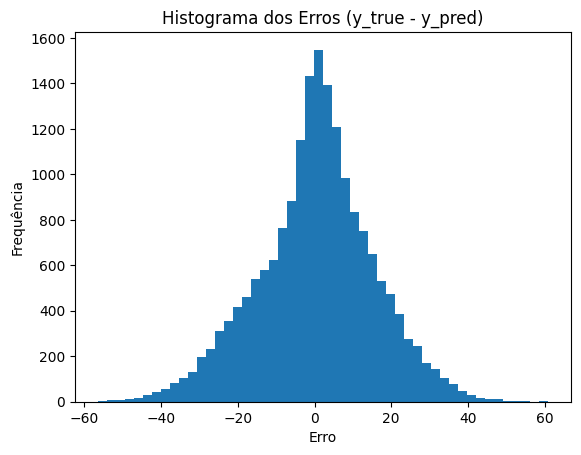

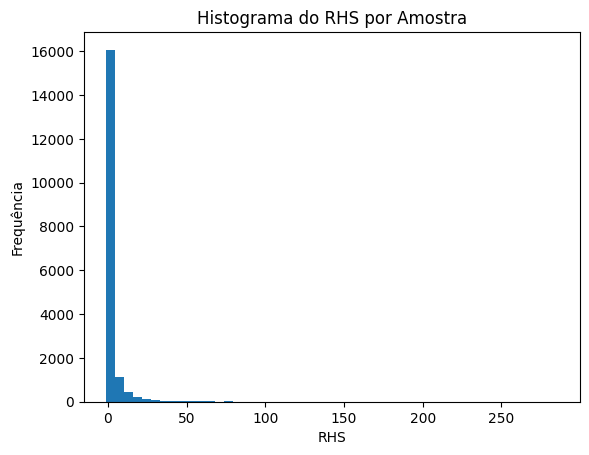

RHS (Training Set): 3.89


In [16]:
import matplotlib.pyplot as plt

# Previsões e erros
y_pred_train = model.predict(X_train).flatten()
errors = y_train - y_pred_train

# Histograma dos erros
plt.figure()
plt.hist(errors, bins=50)
plt.title('Histograma dos Erros (y_true - y_pred)')
plt.xlabel('Erro')
plt.ylabel('Frequência')
plt.show()

# Calcula o RHS por amostra seguindo o paper
d = y_pred_train - y_train
rhs_samples = np.where(
    d < 0,
    np.exp(d / 13.0) - 1.0,   # under-prediction
    np.exp(d / 10.0) - 1.0    # over-prediction
)

# Plota histograma do RHS por amostra
plt.figure()
plt.hist(rhs_samples, bins=50)
plt.title('Histograma do RHS por Amostra')
plt.xlabel('RHS')
plt.ylabel('Frequência')
plt.show()

# Cálculo manual do RHS
rhs_train = rul_health_score(y_train, y_pred_train)
print(f'RHS (Training Set): {rhs_train:.2f}')


In [17]:
def plot_rul_predictions(df, start=1,stop=1, dataset_type='train'):
    """
    Plota a comparação entre RUL real e RUL predito por engine_id.

    Parâmetros:
    - df: DataFrame contendo as colunas ['engine_id', 'cycle', 'RUL', 'RUL_PREDICTED']
    - engines_to_plot: Quantidade de engines a serem exibidas
    - dataset_type: 'train' ou 'test' (apenas para título)
    """
    engine_ids = df["engine_id"].unique()[start-1:stop]

    plt.figure(figsize=(5, 4))

    for engine_id in engine_ids:
        engine_data = df[df["engine_id"] == engine_id]
        plt.plot(engine_data["last_cycle"], engine_data["RUL"], label=f'Engine {engine_id} - Real', linestyle='-')
        plt.plot(engine_data["last_cycle"], engine_data["RUL_PREDICTED"], label=f'Engine {engine_id} - Predicted', linestyle='--')

    plt.xlabel('last_cycle')
    plt.ylabel('RUL')
    plt.title(f'Comparação RUL Real vs. Predito ({dataset_type.capitalize()} Set)')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_prediction(df, engine_id= 1, dataset_type='train'):

    plt.figure(figsize=(5, 4))

    engine_data = df[df["engine_id"] == engine_id]
    plt.plot(engine_data["last_cycle"], engine_data["RUL"], label=f'Engine {engine_id} - Real', linestyle='-')
    plt.plot(engine_data["last_cycle"], engine_data["RUL_PREDICTED"], label=f'Engine {engine_id} - Predicted', linestyle='--')

    plt.xlabel('last_cycle')
    plt.ylabel('RUL')
    plt.title(f'Comparação RUL Real vs. Predito ({dataset_type.capitalize()} Set)')
    plt.legend()
    plt.grid(True)
    plt.show()

573/573 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


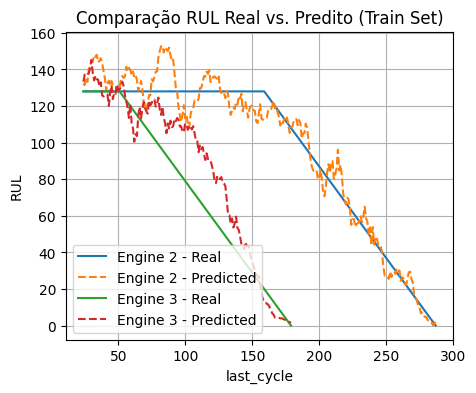

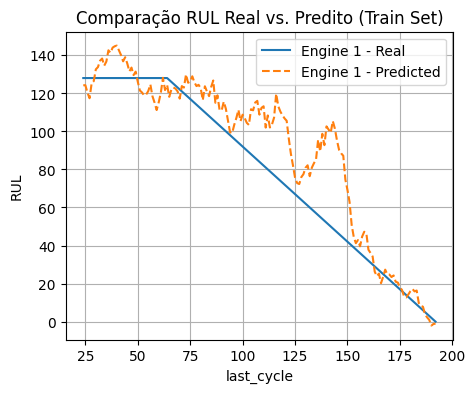

In [18]:
df_train_windows = df_train_windows.reset_index(drop=True)

# Criando o DataFrame de resultados
df_results = df_train_windows[["engine_id", "RUL", "last_cycle"]].copy()

df_results['RUL_PREDICTED'] = model.predict(X_train)

plot_rul_predictions(df_results, start=2,stop=3,dataset_type='train')
plot_prediction(df=df_results, engine_id=1, dataset_type='train')

# Avaliando no conjunto de teste

In [19]:
df_rul['engine_id'] = df_rul.index + 1
display(df_rul.head())

,RUL,engine_id
0,112,1
1,98,2
2,69,3
3,82,4
4,91,5


### preparando os dados de teste

In [20]:
import numpy as np

# Parâmetros
window_size = 24
sensor_cols  = selected_sensors  # mesma lista do treino

# Supondo que df_rul tenha colunas ['engine_id', 'RUL']
# (chamei aqui de true_RUL para evitar confusão)
df_rul = df_rul.rename(columns={'RUL':'true_RUL'})

# Geração das janelas e labels
X_test = []
y_test = []

for eid, group in df_test.groupby('engine_id', sort=False):
    data = group[sensor_cols].values
    # Pega só a última janela completa
    window = data[-window_size:]
    X_test.append(window.flatten())
    # Usa o RUL “verdadeiro” do df_rul
    y_test.append(
        df_rul.loc[df_rul['engine_id']==eid, 'true_RUL'].item()
    )

# Converte para arrays
X_test = np.stack(X_test)   # shape (n_engines, window_size * n_sensores)
y_test = np.array(y_test)   # shape (n_engines,)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
RHS médio (Test Set): 2.30


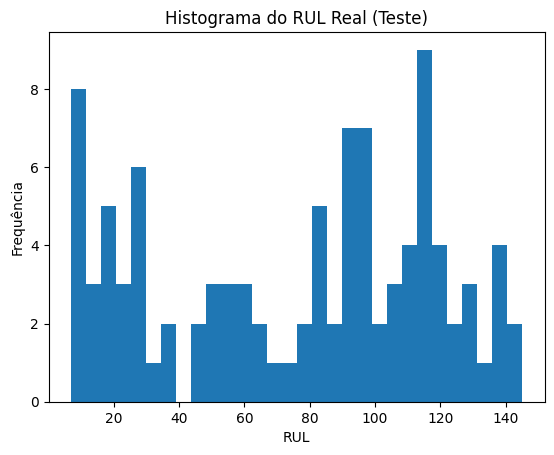

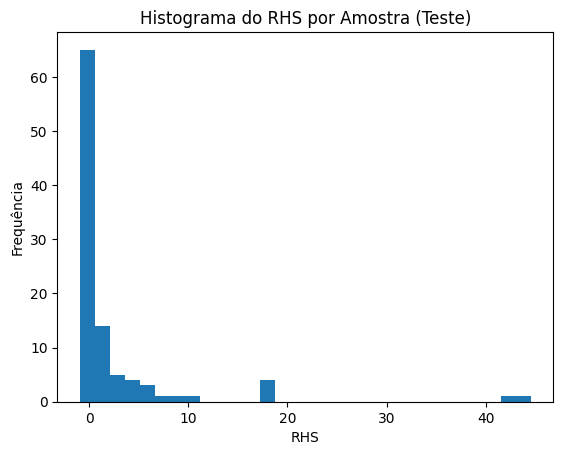

In [21]:
# 3.1 – Predição
y_pred_test = model.predict(X_test).flatten()

# 3.2 – RHS por amostra (mesma fórmula do paper)
d_test       = y_pred_test - y_test
rhs_samples  = np.where(
    d_test < 0,
    np.exp(d_test / 13.0) - 1.0,
    np.exp(d_test / 10.0) - 1.0
)
rhs_mean_test = rhs_samples.mean()

# 3.3 – Impressão e histogramas
print(f'RHS médio (Test Set): {rhs_mean_test:.2f}')

import matplotlib.pyplot as plt

plt.figure()
plt.hist(y_test, bins=30)
plt.title('Histograma do RUL Real (Teste)')
plt.xlabel('RUL')
plt.ylabel('Frequência')
plt.show()

plt.figure()
plt.hist(rhs_samples, bins=30)
plt.title('Histograma do RHS por Amostra (Teste)')
plt.xlabel('RHS')
plt.ylabel('Frequência')
plt.show()


,Artigo,Meu Modelo
Métrica,,
RHS (Test Set),16.22,2.300922
RMSE (Test Set),5.98,14.915333


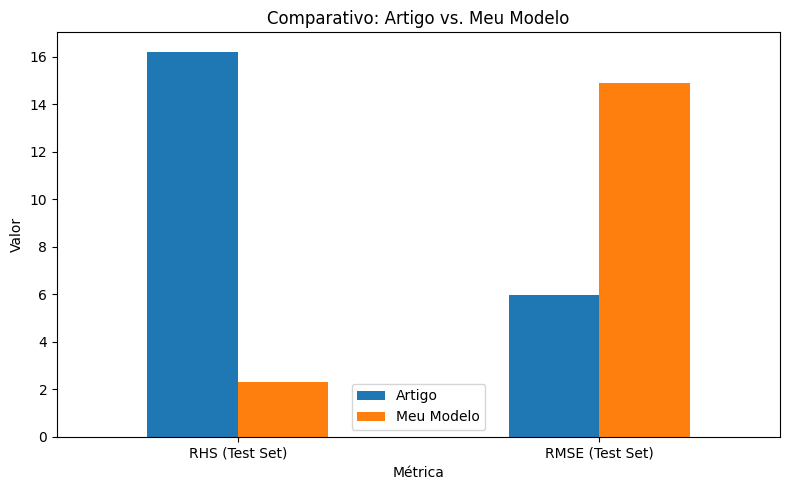

In [25]:
# 1) Defina aqui os valores reportados no artigo
article_metrics = {
    'RHS (Test Set)': 16.22,   # ex: valor do artigo
    'RMSE (Test Set)': 5.98  # ex: valor do artigo
}

# 2) Defina aqui os valores que você obteve
my_metrics = {
    'RHS (Test Set)': rhs_mean_test,  # já calculado no seu fluxo
    'RMSE (Test Set)': float(root_mean_squared_error(y_test, y_pred_test).numpy())  # ou calcule seu RMSE manualmente
}

# 3) Monte o DataFrame comparativo
df_cmp = pd.DataFrame({
    'Artigo': article_metrics,
    'Meu Modelo': my_metrics
})
df_cmp.index.name = 'Métrica'
display(df_cmp)

# 4) Plot de barras
ax = df_cmp.plot.bar(rot=0, figsize=(8,5))
ax.set_ylabel('Valor')
ax.set_title('Comparativo: Artigo vs. Meu Modelo')
plt.tight_layout()
plt.show()


In [33]:
# Salvando o modelo

save_dir = './turbofan_artifacts/architecture_1'
os.makedirs(save_dir, exist_ok=True)
print('Salvando artefatos em:', save_dir)

Salvando artefatos em: ./turbofan_artifacts/architecture_1


In [36]:
model.summary()
model_path = os.path.join(save_dir, 'turbofan_mlp_model.keras')
model.save(model_path)
print('Modelo salvo em:', model_path)


Model: "Arquitetura-1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 20)             │         6,740 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,181 (28.05 KB)

 Trainable params: 7,181 (28.05 KB)

 Non-trainable params: 0 (0.00 B)

Modelo salvo em: ./turbofan_artifacts/architecture_1/turbofan_mlp_model.keras


In [34]:
import json

history_path = os.path.join(save_dir, 'history.json')
with open(history_path, 'w') as f:
    json.dump(history.history, f, indent=2)
print('History salvo em:', history_path)


History salvo em: ./turbofan_artifacts/architecture_1/history.json


In [35]:
csv_path = os.path.join(save_dir, 'metrics.csv')
df_cmp.to_csv(csv_path)

print('Métricas salvas em:', csv_path)

Métricas salvas em: ./turbofan_artifacts/architecture_1/metrics.csv


In [32]:
!pwd

/content/drive/MyDrive/Data science studies/Aprendizado-de-maquina-UFSC/final-project/data


In [37]:
# Check the contents of the save directory
!ls -lR {save_dir}

./turbofan_artifacts/architecture_1:
total 61
-rw------- 1 root root  9380 Jul  2 20:31 history.json
-rw------- 1 root root   107 Jul  2 20:31 metrics.csv
-rw------- 1 root root 51398 Jul  2 20:33 turbofan_mlp_model.keras


In [38]:
from tensorflow.keras.models import load_model
import os

# Define the path to the saved model
save_dir = './turbofan_artifacts/architecture_1'
model_path = os.path.join(save_dir, 'turbofan_mlp_model.keras')

# Load the model
loaded_model = load_model(model_path, custom_objects={'rul_health_score': rul_health_score})

# Evaluate the loaded model on the test data
loss, mse, rmse, rhs = loaded_model.evaluate(X_test, y_test, verbose=0)

print(f"Evaluation on Test Set:")
print(f"  Loss: {loss:.4f}")
print(f"  MSE: {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  RUL Health Score: {rhs:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


TypeError: Input 'y' of 'Sub' Op has type int64 that does not match type float32 of argument 'x'.